<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Pie Charts**


Estimated time needed: **30** minutes


- In this lab, you will focus on visualizing data.

- The provided dataset will be loaded into pandas for analysis.

- Various pie charts will be created to:
   - Analyze developer preferences.
  
   - Identify technology usage trends.
    
- The lab aims to provide insights into key variables using visual representations.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize composition of data.

-   Visualize comparison of data.


## Setup: Downloading and Loading the Data
**Install the libraries**


In [2]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 153.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 167.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]


In [3]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 112.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 120.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 77.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 157.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]


**Download and Load the Data**


To start, download and load the dataset into a `pandas` DataFrame.



In [4]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Step 2: Import necessary libraries and load the dataset
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows to understand the structure of the data
df.head()


--2026-09-25 16:04:16--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  34.6MB/s    in 4.3s    

2026-09-25 16:04:21 (35.2 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Visualizing Data Composition with Pie Charts


##### 1.1 Create a Pie Chart of the Top 5 Databases Respondents Want to Work With


In the survey data, the `DatabaseWantToWorkWith` column lists the databases that respondents wish to work with. Let’s visualize the top 5 most-desired databases in a pie chart.



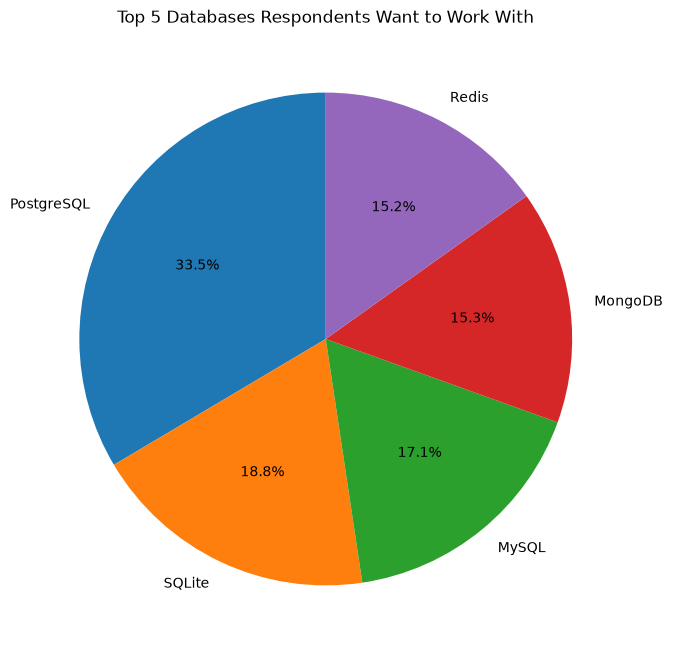

In [5]:
##Write your code here
# Count each database
database_data = (
    df["DatabaseWantToWorkWith"]
    .dropna()
    .str.split(";")
    .explode()
    .str.strip()
)

top_5_databases = database_data.value_counts().head(5)

# Create pie chart
plt.figure(figsize=(8, 8))

plt.pie(
    top_5_databases.values,
    labels=top_5_databases.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Top 5 Databases Respondents Want to Work With")

plt.show()

The `DevType` column lists the developer types for respondents. We’ll examine the distribution by showing the top 5 developer roles in a pie chart.



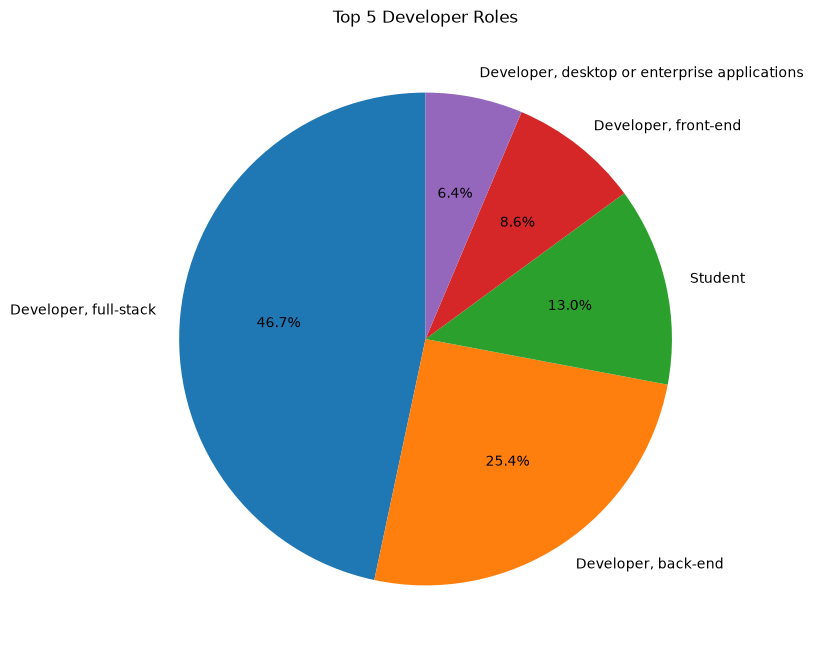

In [6]:
##Write your code here
# Count each developer role
devtype_data = (
    df["DevType"]
    .dropna()
    .str.split(";")
    .explode()
    .str.strip()
)

top_5_devtypes = devtype_data.value_counts().head(5)

# Create pie chart
plt.figure(figsize=(8, 8))

plt.pie(
    top_5_devtypes.values,
    labels=top_5_devtypes.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Top 5 Developer Roles")

plt.show()

##### 1.3 Create a pie chart for the operating systems used by respondents for professional use


The `OpSysProfessional` use column shows the operating systems developers use professionally. Let’s visualize the distribution of the top operating systems in a pie chart.



In [8]:
##Write your code here
# Show columns containing "OpSys"
[col for col in df.columns if "OpSys" in col]

['OpSysPersonal use', 'OpSysProfessional use']

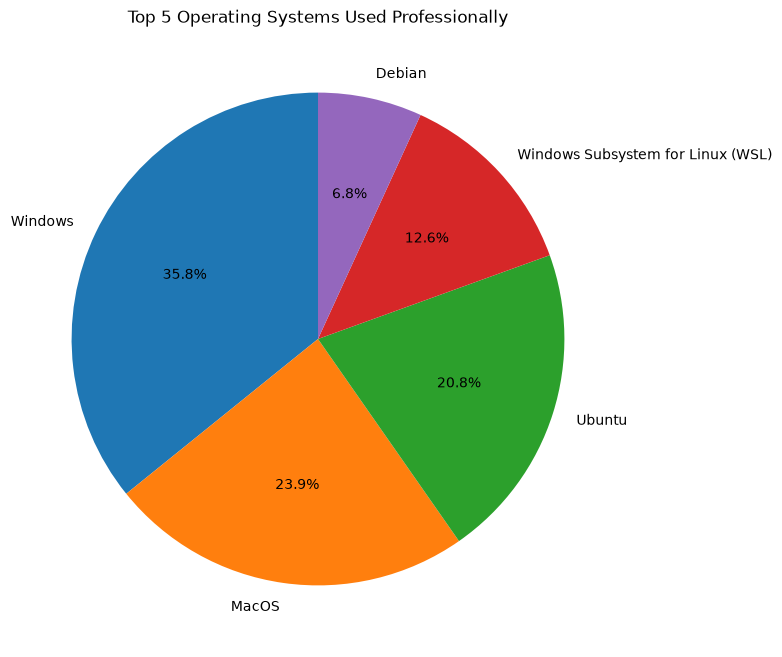

In [9]:
# Count operating systems used professionally
os_data = (
    df["OpSysProfessional use"]
    .dropna()
    .str.split(";")
    .explode()
    .str.strip()
)

# Get top 5 operating systems
top_os = os_data.value_counts().head(5)

# Create pie chart
plt.figure(figsize=(8, 8))

plt.pie(
    top_os.values,
    labels=top_os.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Top 5 Operating Systems Used Professionally")

plt.show()

### Task 2: Additional Visualizations and Comparisons


##### 2.1 Pie Chart for Top 5 Programming Languages Respondents Have Worked With


The `LanguageHaveWorkedWith` column contains the programming languages that respondents have experience with. We’ll plot a pie chart to display the composition of the top 5 languages.



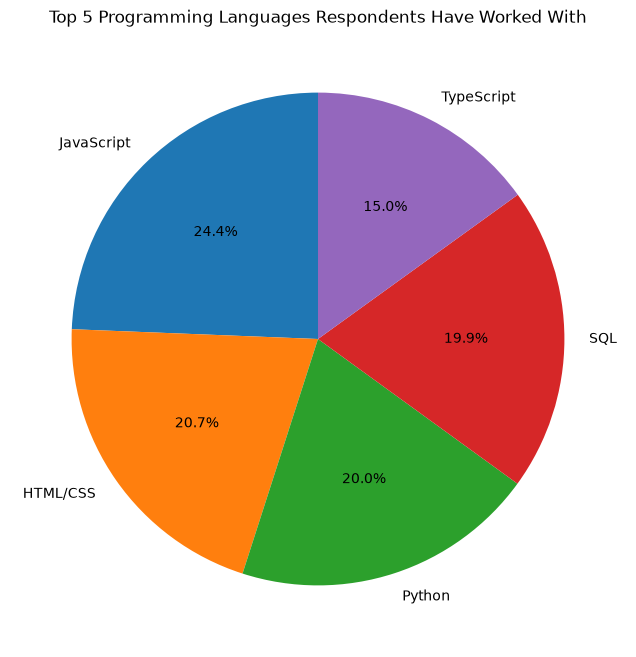

In [10]:
##Write your code here
# Count programming languages
language_data = (
    df["LanguageHaveWorkedWith"]
    .dropna()
    .str.split(";")
    .explode()
    .str.strip()
)

top_5_languages = language_data.value_counts().head(5)

# Create pie chart
plt.figure(figsize=(8, 8))

plt.pie(
    top_5_languages.values,
    labels=top_5_languages.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Top 5 Programming Languages Respondents Have Worked With")

plt.show()

##### 2.2 Pie Chart for Top Collaboration Tools used in Professional Use


Using the `NEWCollabToolsHaveWorkedWith` column, we’ll identify and visualize the top collaboration tools respondents use in their professional work.



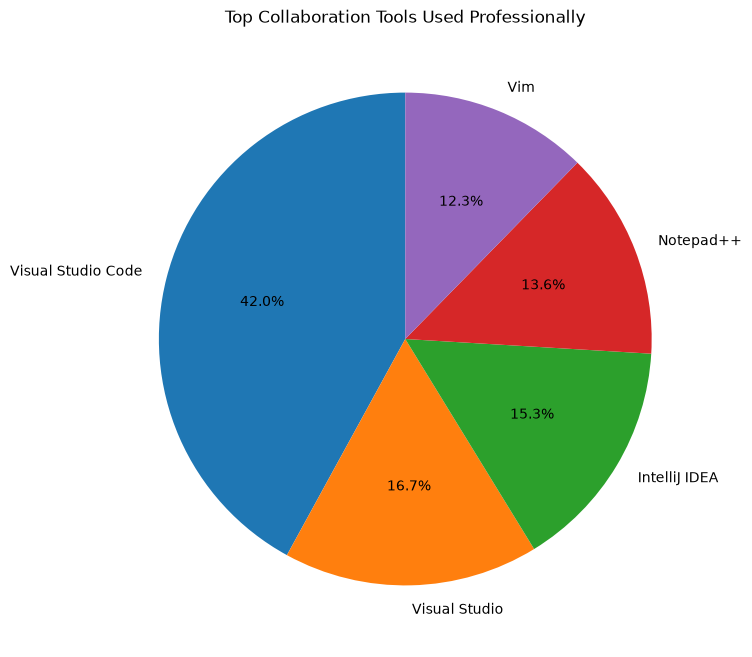

In [11]:
##Write your code here
# Count collaboration tools
collab_data = (
    df["NEWCollabToolsHaveWorkedWith"]
    .dropna()
    .str.split(";")
    .explode()
    .str.strip()
)

top_5_collab_tools = collab_data.value_counts().head(5)

# Create pie chart
plt.figure(figsize=(8, 8))

plt.pie(
    top_5_collab_tools.values,
    labels=top_5_collab_tools.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Top Collaboration Tools Used Professionally")

plt.show()

### Task 3: Analyzing and Interpreting Composition


In this task, you will create additional pie charts to analyze specific aspects of the survey data. Use `pandas` and `matplotlib` to complete each task and interpret the findings.



##### 3.1 Pie Chart of `Respondents` Most Admired Programming Languages


The `LanguageAdmired` column lists the programming languages respondents admire most. Create a pie chart to visualize the top 5 admired languages.



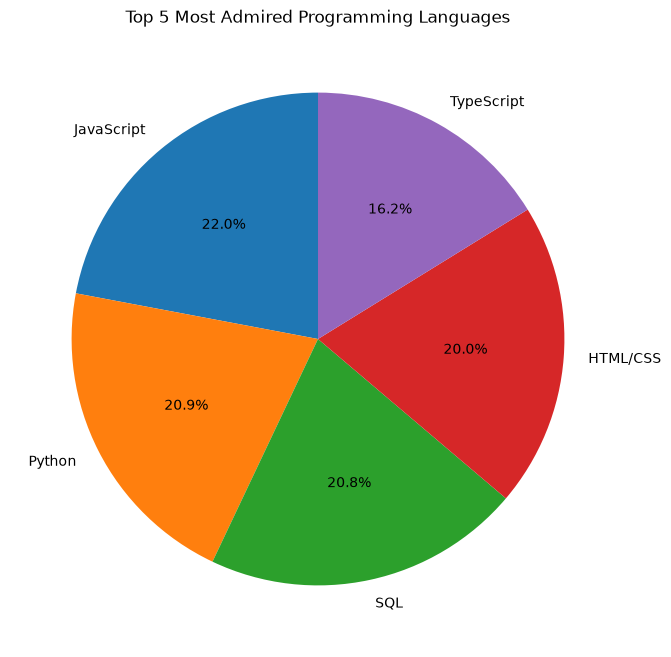

In [12]:
##Write your code here
# Count admired programming languages
admired_languages = (
    df["LanguageAdmired"]
    .dropna()
    .str.split(";")
    .explode()
    .str.strip()
)

top_5_admired = admired_languages.value_counts().head(5)

# Create pie chart
plt.figure(figsize=(8, 8))

plt.pie(
    top_5_admired.values,
    labels=top_5_admired.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Top 5 Most Admired Programming Languages")

plt.show()

##### 3.2 Pie Chart of Tools Used for AI Development


Using the `AIToolCurrently` Using column, create a pie chart to visualize the top 5 tools developers are currently using for AI development.



In [14]:
##Write your code here
# Find columns related to AI tools
[col for col in df.columns if "AI" in col or "AITool" in col]

['AISearchDevHaveWorkedWith',
 'AISearchDevWantToWorkWith',
 'AISearchDevAdmired',
 'AISelect',
 'AISent',
 'AIBen',
 'AIAcc',
 'AIComplex',
 'AIToolCurrently Using',
 'AIToolInterested in Using',
 'AIToolNot interested in Using',
 'AINextMuch more integrated',
 'AINextNo change',
 'AINextMore integrated',
 'AINextLess integrated',
 'AINextMuch less integrated',
 'AIThreat',
 'AIEthics',
 'AIChallenges']

AI-related columns found: ['MainBranch', 'AISearchDevHaveWorkedWith', 'AISearchDevWantToWorkWith', 'AISearchDevAdmired', 'AISelect', 'AISent', 'AIBen', 'AIAcc', 'AIComplex', 'AIToolCurrently Using', 'AIToolInterested in Using', 'AIToolNot interested in Using', 'AINextMuch more integrated', 'AINextNo change', 'AINextMore integrated', 'AINextLess integrated', 'AINextMuch less integrated', 'AIThreat', 'AIEthics', 'AIChallenges']

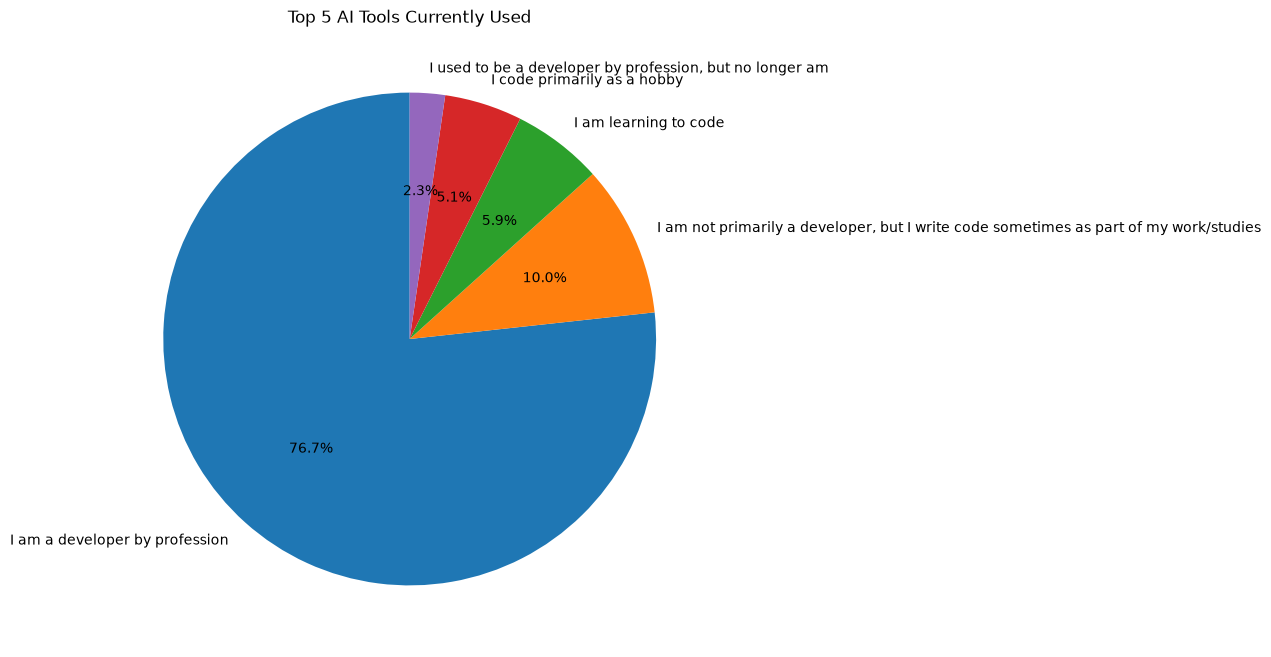

In [15]:
# Find the AI tools column
ai_columns = [col for col in df.columns if "AI" in col.upper()]

print("AI-related columns found:", ai_columns)

# Use the AI tools column
ai_column = ai_columns[0]

# Count AI tools
ai_tools = (
    df[ai_column]
    .dropna()
    .astype(str)
    .str.split(";")
    .explode()
    .str.strip()
)

top_5_ai_tools = ai_tools.value_counts().head(5)

# Create pie chart
plt.figure(figsize=(8, 8))

plt.pie(
    top_5_ai_tools.values,
    labels=top_5_ai_tools.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Top 5 AI Tools Currently Used")

plt.show()

##### 3.3 Pie Chart for Preferred Web Frameworks


The `WebframeWantToWorkWith` column includes web frameworks that respondents are interested in working with. Visualize the top 5 frameworks in a pie chart.



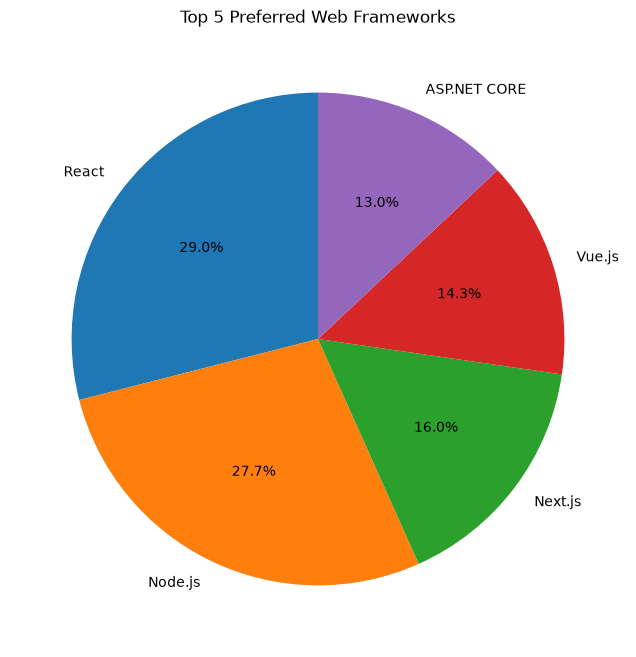

In [16]:
##Write your code here
# Count web frameworks
web_frameworks = (
    df["WebframeWantToWorkWith"]
    .dropna()
    .str.split(";")
    .explode()
    .str.strip()
)

top_5_frameworks = web_frameworks.value_counts().head(5)

# Create pie chart
plt.figure(figsize=(8, 8))

plt.pie(
    top_5_frameworks.values,
    labels=top_5_frameworks.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Top 5 Preferred Web Frameworks")

plt.show()

##### 3.4 Pie Chart for Most Desired Embedded Technologies


Using the `EmbeddedWantToWorkWith` column, create a pie chart to show the top 5 most desired embedded technologies that respondents wish to work with.



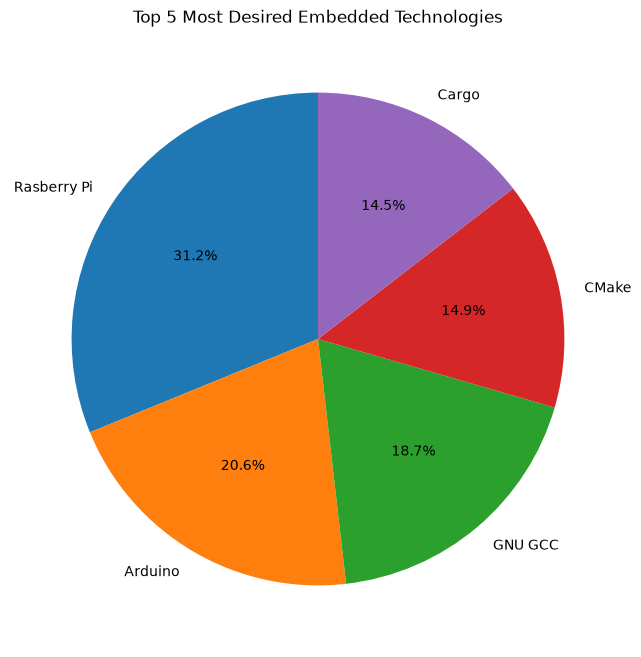

In [17]:
##Write your code here
# Count embedded technologies
embedded_tech = (
    df["EmbeddedWantToWorkWith"]
    .dropna()
    .str.split(";")
    .explode()
    .str.strip()
)

top_5_embedded = embedded_tech.value_counts().head(5)

# Create pie chart
plt.figure(figsize=(8, 8))

plt.pie(
    top_5_embedded.values,
    labels=top_5_embedded.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Top 5 Most Desired Embedded Technologies")

plt.show()

### Summary


After completing this lab, you will be able to:
- Create pie charts to visualize developer preferences across databases, programming languages, AI tools, and cloud platforms.
- Identify trends in technology usage, role distribution, and tool adoption through pie charts.
- Analyze and compare data composition across various categories to gain insights into developer preferences.




## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
